In [51]:
##### Step 1: import functions #####
from keras.layers import Dense, Flatten, BatchNormalization, Activation, Conv2D, AveragePooling2D, Input
from keras.layers import MaxPooling2D, Dropout
from keras.models import load_model, Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import pickle
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import keras as keras
keras.utils.set_random_seed(123)
from sklearn.metrics import roc_curve, auc
from six import StringIO 
from sklearn.tree import export_graphviz, DecisionTreeRegressor
from scipy.stats import ttest_ind
from IPython.display import Image  
import pydotplus
from keras.regularizers import L1L2
import os

In [52]:
os.chdir('/Users/elijahwillie/Documents/PhD/DeepLearning_CyTOF/Breast_Cancer_Wagner_2019/')

In [53]:
##### load data #####
allData = pd.compat.pickle_compat.load(open("breast_cancer_allData.obj", "rb" ))
metaData = allData["cytof_files"]
cytoData = allData["expr_list"]
markerNames = allData["marker_names"]

In [54]:
##### split train, validation and test######
##### Step 3: split train, validation and test######
y = metaData.y.values
x = cytoData

train_id = metaData.dataset =="train"
# valid_id = metaData.dataset =="valid"
test_id = metaData.dataset =="test"

x_train = x[train_id]; y_train = y[train_id]
# x_valid = x[valid_id]; y_valid = y[valid_id]
x_test = x[test_id]; y_test = y[test_id]

In [55]:
##### Step 4: define model #####
# input
model_input = Input(shape=x_train[0].shape)

# first convolution layer
model_output = Conv2D(3, kernel_size=(1, x_train.shape[2]),
                 activation=None)(model_input)
model_output = BatchNormalization()(model_output)
model_output = Activation("relu")(model_output)

# sceond convolution layer
model_output = Conv2D(3, (1, 1), activation=None)(model_output)
model_output = BatchNormalization()(model_output)
model_output = Activation("relu")(model_output)

# pooling layer
model_output = AveragePooling2D(pool_size=(x_train.shape[1], 1))(model_output)
model_output = Flatten()(model_output)

# Dense layer
model_output = Dense(3, activation=None)(model_output)
model_output = BatchNormalization()(model_output)
model_output = Activation("relu")(model_output)

# output layer
model_output = Dense(1, activation=None)(model_output)
model_output = BatchNormalization()(model_output)
model_output = Activation("sigmoid")(model_output)

In [15]:
##### Step 5: Fit model #####

# specify input and output
model = Model(inputs=[model_input],
              outputs=model_output)

# define loss function and optimizer
model.compile(loss='binary_crossentropy',
              optimizer=Adam(lr=0.01),
              metrics=['accuracy'])

# save the best performing model
checkpointer = ModelCheckpoint(filepath='breast_cancer_deep_cnn_weights.hdf5', 
                               monitor='val_loss', verbose=1,
                               save_best_only=True)

# model training
model.fit([x_train], y_train,
          batch_size=60,
          epochs=200, 
          verbose=1,
          callbacks=[checkpointer],
          validation_split = 0.3)

Epoch 1/200


/opt/anaconda3/envs/CyTOF_DL/lib/python3.11/site-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


1/2 [==============>...............] - ETA: 0s - loss: 1.8512 - accuracy: 0.3500
Epoch 1: val_loss improved from inf to 0.84420, saving model to DL_CyTOF/breast_cancer_deepCyTOF_saved_weights.hdf5
2/2 [==============================] - 0s 121ms/step - loss: 1.5801 - accuracy: 0.3407 - val_loss: 0.8442 - val_accuracy: 0.2564
Epoch 2/200
1/2 [==============>...............] - ETA: 0s - loss: 0.7989 - accuracy: 0.3167
Epoch 2: val_loss improved from 0.84420 to 0.67283, saving model to DL_CyTOF/breast_cancer_deepCyTOF_saved_weights.hdf5
2/2 [==============================] - 0s 50ms/step - loss: 0.7678 - accuracy: 0.3956 - val_loss: 0.6728 - val_accuracy: 0.8974
Epoch 3/200
1/2 [==============>...............] - ETA: 0s - loss: 0.7024 - accuracy: 0.5500
Epoch 3: val_loss improved from 0.67283 to 0.65092, saving model to DL_CyTOF/breast_cancer_deepCyTOF_saved_weights.hdf5
2/2 [==============================] - 0s 48ms/step - loss: 0.6910 - accuracy: 0.6044 - val_loss: 0.6509 - val_accuracy:

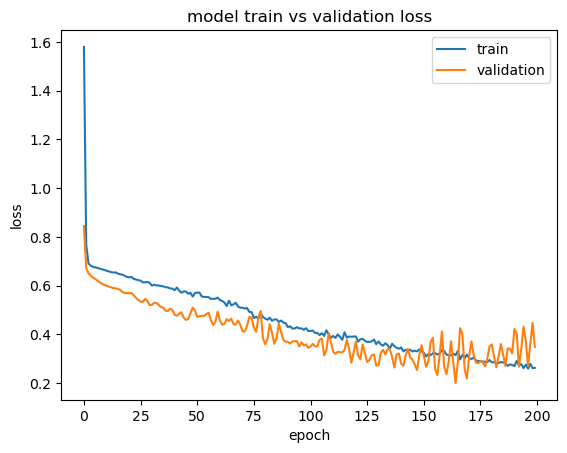

In [16]:
##### Step 6: plot train and validation loss #####
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model train vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

2/2 [==============================] - 0s 6ms/step


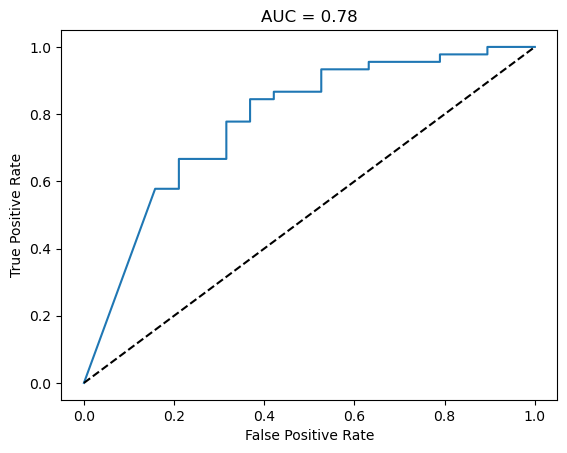

In [17]:
##### Step 7: test the final model #####

# load final model
final_model = load_model('breast_cancer_deep_cnn_weights.hdf5')

# generate ROC and AUC
y_scores = final_model.predict([x_test])
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC = {0:.2f}'.format(roc_auc))
plt.show()

In [18]:
y_scores = pd.DataFrame(np.column_stack([list(y_test), list(y_scores.flatten())]), columns=['truth', 'pred'])
y_scores.to_csv('breast_cancer_deep_cytof_aucs.csv', sep=',')

# Fit Cell CNN

In [56]:
coeff_l1 = 0
coeff_l2 = 1e-4
model_input = Input(shape=x_train[0].shape)
model_output = Conv2D(5, kernel_size=(1, x_train.shape[2]),
                 activation='linear', 
                      kernel_regularizer=L1L2(l1=coeff_l1, l2=coeff_l2))(model_input)
model_output = Activation("relu")(model_output)

model_output = MaxPooling2D(pool_size=(10000, 1))(model_output)
model_output = Flatten()(model_output)

model_output = Dense(1, activation=None, kernel_regularizer=L1L2(l1=coeff_l1, l2=coeff_l2))(model_output)
model_output = Activation("sigmoid")(model_output)

model = Model(inputs=[model_input],
                           outputs=model_output)
model.compile(loss='binary_crossentropy',
              optimizer = Adam(lr=0.01),
              metrics=['accuracy'])

checkpointer = keras.callbacks.ModelCheckpoint(filepath='breast_cancer_cell_cnn_weights.hdf5', monitor='val_loss', 
                                               verbose=1, save_best_only=True)
earlyStop = keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.00000001, patience=100, 
                                          verbose=0, mode='auto', baseline=None, restore_best_weights=True)

/opt/anaconda3/envs/CyTOF_DL/lib/python3.11/site-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [57]:
model.fit([x_train], y_train,
          batch_size=60,
          epochs=200,
          verbose=1,
          callbacks=[checkpointer,earlyStop],
          validation_split=0.3)

Epoch 1/200
1/2 [==============>...............] - ETA: 0s - loss: 1.7599 - accuracy: 0.6500
Epoch 1: val_loss improved from inf to 0.41134, saving model to DL_CyTOF/breast_cancer_cnn_saved_weights.hdf5
2/2 [==============================] - 0s 92ms/step - loss: 1.5147 - accuracy: 0.6593 - val_loss: 0.4113 - val_accuracy: 0.9231
Epoch 2/200
1/2 [==============>...............] - ETA: 0s - loss: 0.6775 - accuracy: 0.6333
Epoch 2: val_loss did not improve from 0.41134
2/2 [==============================] - 0s 33ms/step - loss: 0.7370 - accuracy: 0.5495 - val_loss: 1.4426 - val_accuracy: 0.0256
Epoch 3/200
1/2 [==============>...............] - ETA: 0s - loss: 0.9375 - accuracy: 0.3333
Epoch 3: val_loss did not improve from 0.41134
2/2 [==============================] - 0s 32ms/step - loss: 0.9164 - accuracy: 0.3407 - val_loss: 0.8833 - val_accuracy: 0.3846
Epoch 4/200
1/2 [==============>...............] - ETA: 0s - loss: 0.6932 - accuracy: 0.5333
Epoch 4: val_loss improved from 0.41134 

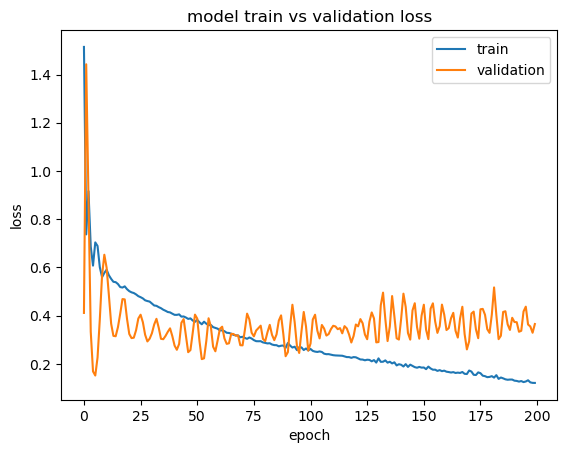

In [58]:
# plot train and validation loss
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model train vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [59]:
best_model = load_model('breast_cancer_cell_cnn_weights.hdf5')

# print result of the best model
score = best_model.evaluate([x_train], y_train, verbose=0)
print('Train loss:', score[0])
print('Train accuracy:', score[1])

# score = best_model.evaluate([x_valid], y_valid, verbose=0)
# print('Valid loss:', score[0])
# print('Valid accuracy:', score[1])

score = best_model.evaluate([x_test], y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train loss: 0.5364011526107788
Train accuracy: 0.7615384459495544
Test loss: 0.5928385257720947
Test accuracy: 0.703125


2/2 [==============================] - 0s 5ms/step


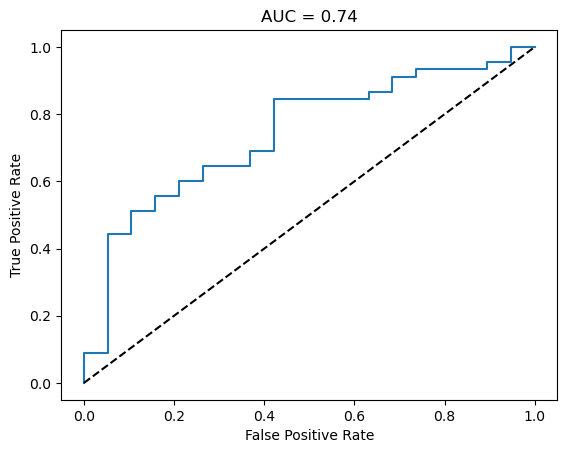

In [60]:
# generate ROC and AUC
y_scores = best_model.predict([x_test])
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC = {0:.2f}'.format(roc_auc))
plt.show()

In [61]:
y_scores = pd.DataFrame(np.column_stack([list(y_test), list(y_scores.flatten())]), columns=['truth', 'pred'])
y_scores.to_csv('breast_cancer_cell_cnn_aucs.csv', sep=',')